In [36]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import gaussian_kde, norm
import pandas as pd

sys.path.insert(0, str(Path('..').resolve().parent))
from config.preprocess_config import T
from evaluate import fisher_kurtosis, acf_squared

Path('../../figures').mkdir(parents=True, exist_ok=True)


In [37]:
"""
Plot configs.
"""

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

C_CA_NORM = 'tab:blue'
C_CA_STRESS = 'tab:green'
C_FILM_NORM = 'tab:red'
C_FILM_STRESS = 'tab:orange'
C_NORMAL = 'tab:red'

# (model_dir_key, macro_key, color, label)
GROUPS = [
    ('ca', 'normal', C_CA_NORM, 'CA + Normal'),
    ('ca', 'stress', C_CA_STRESS, 'CA + Stress'),
    ('ca-film', 'normal', C_FILM_NORM, 'FiLM + Normal'),
    ('ca-film', 'stress', C_FILM_STRESS, 'FiLM + Stress'),
]

print("Plot config defined.")


Plot config defined.


In [38]:
"""
Load generated data (9 micro-condition cells x 4 groups).
"""

MODEL_DIRS = {
    'ca': Path('../../data/generated/ca'),
    'ca-film': Path('../../data/generated/ca-film'),
}

TRENDS = [-10, 0, 10]
RVS = [30, 50, 70]

MACROS = {'normal': (5,  20), 'stress': (8,  35)}

# Get data
gen_data = {}
for model, base_dir in MODEL_DIRS.items():
    for macro_key, (ir, vix) in MACROS.items():
        group_key = (model, macro_key)
        gen_data[group_key] = {}
        for trend in TRENDS:
            for rv in RVS:
                filename = f"t{int(trend)}r{int(rv)}i{int(ir)}v{int(vix)}.json"
                with open(base_dir / filename) as f:
                    payload = json.load(f)
                samples = np.array(payload['samples'], dtype=np.float64)  # (N, T)

                # Inverse normalisation
                mean_w = payload['conditions']['trend'] / (100.0 * T)
                var_w  = (payload['conditions']['realized_vol'] / (100.0 ** 2) - T * mean_w ** 2) / (T - 1)
                std_w  = np.sqrt(np.maximum(var_w, 1e-12))
                samples_pct = (samples * std_w + mean_w) * 100.0       # percentage units

                gen_data[group_key][(trend, rv)] = samples_pct

# Print shape summary
for (model, macro_key), cell_dict in gen_data.items():
    arr = next(iter(cell_dict.values()))
    print(f"[{model} | {macro_key}]: {len(cell_dict)} cells, each {arr.shape[0]} sequences × {arr.shape[1]} steps")


[ca | normal]: 9 cells, each 5000 sequences × 64 steps
[ca | stress]: 9 cells, each 5000 sequences × 64 steps
[ca-film | normal]: 9 cells, each 5000 sequences × 64 steps
[ca-film | stress]: 9 cells, each 5000 sequences × 64 steps


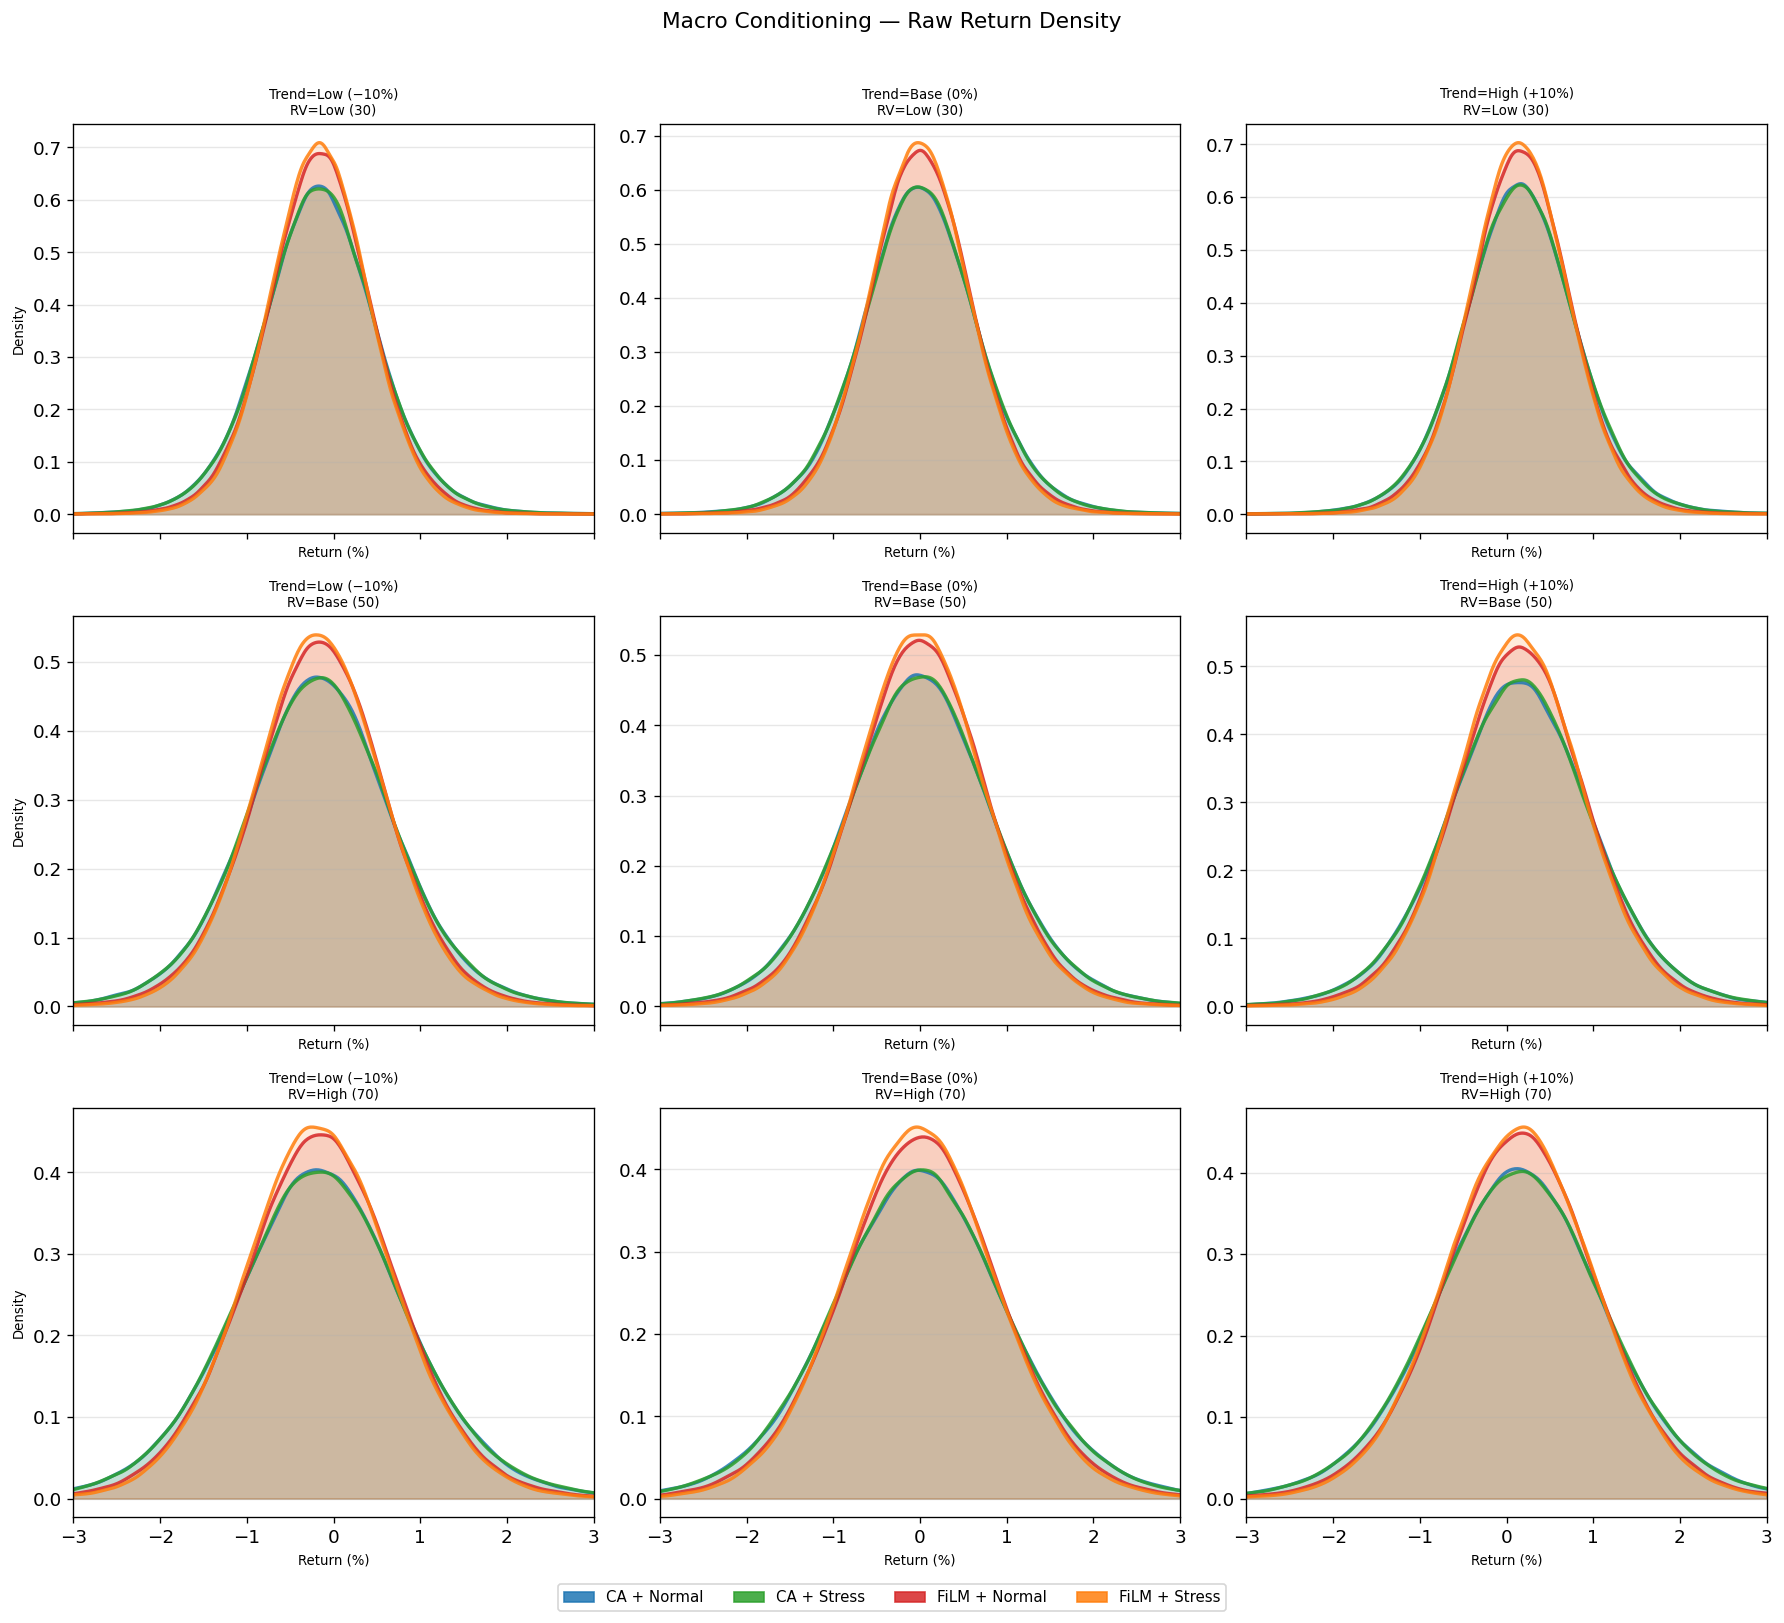

In [39]:
"""
Output 1 — KDE of raw returns distributions.
3×3 grid (RV × trend); 4 overlapping KDE curves per panel.
"""

TREND_LABELS = {-10: 'Low (−10%)', 0: 'Base (0%)', 10: 'High (+10%)'}
RV_LABELS    = {30: 'Low (30)', 50: 'Base (50)', 70: 'High (70)'}

x_grid = np.linspace(-3, 3, 400)

fig, axes = plt.subplots(3, 3, figsize=(15, 13), sharex=True, sharey=False)

for row_idx, rv in enumerate(RVS):
    for col_idx, trend in enumerate(TRENDS):
        ax = axes[row_idx, col_idx]

        for model, macro_key, color, label in GROUPS:
            arr = gen_data[(model, macro_key)][(trend, rv)]  # (N, T)
            flat = arr.ravel()
            kde_vals = gaussian_kde(flat, bw_method='scott')(x_grid)
            ax.plot(x_grid, kde_vals, color=color, lw=2, alpha=0.85, label=label)
            ax.fill_between(x_grid, kde_vals, color=color, alpha=0.15)

        ax.set_xlim(x_grid[0], x_grid[-1])
        ax.set_xlabel('Return (%)', fontsize=8)
        ax.set_title(f'Trend={TREND_LABELS[trend]}\nRV={RV_LABELS[rv]}', fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    axes[row_idx, 0].set_ylabel('Density', fontsize=8)

# Shared legend
handles = [mpatches.Patch(color=g[2], alpha=0.85, label=g[3]) for g in GROUPS]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Macro Conditioning — Raw Return Density', fontsize=13, y=1.01)

plt.tight_layout()
plt.savefig('../../figures/macro_kde_raw.png', bbox_inches='tight')
plt.show()


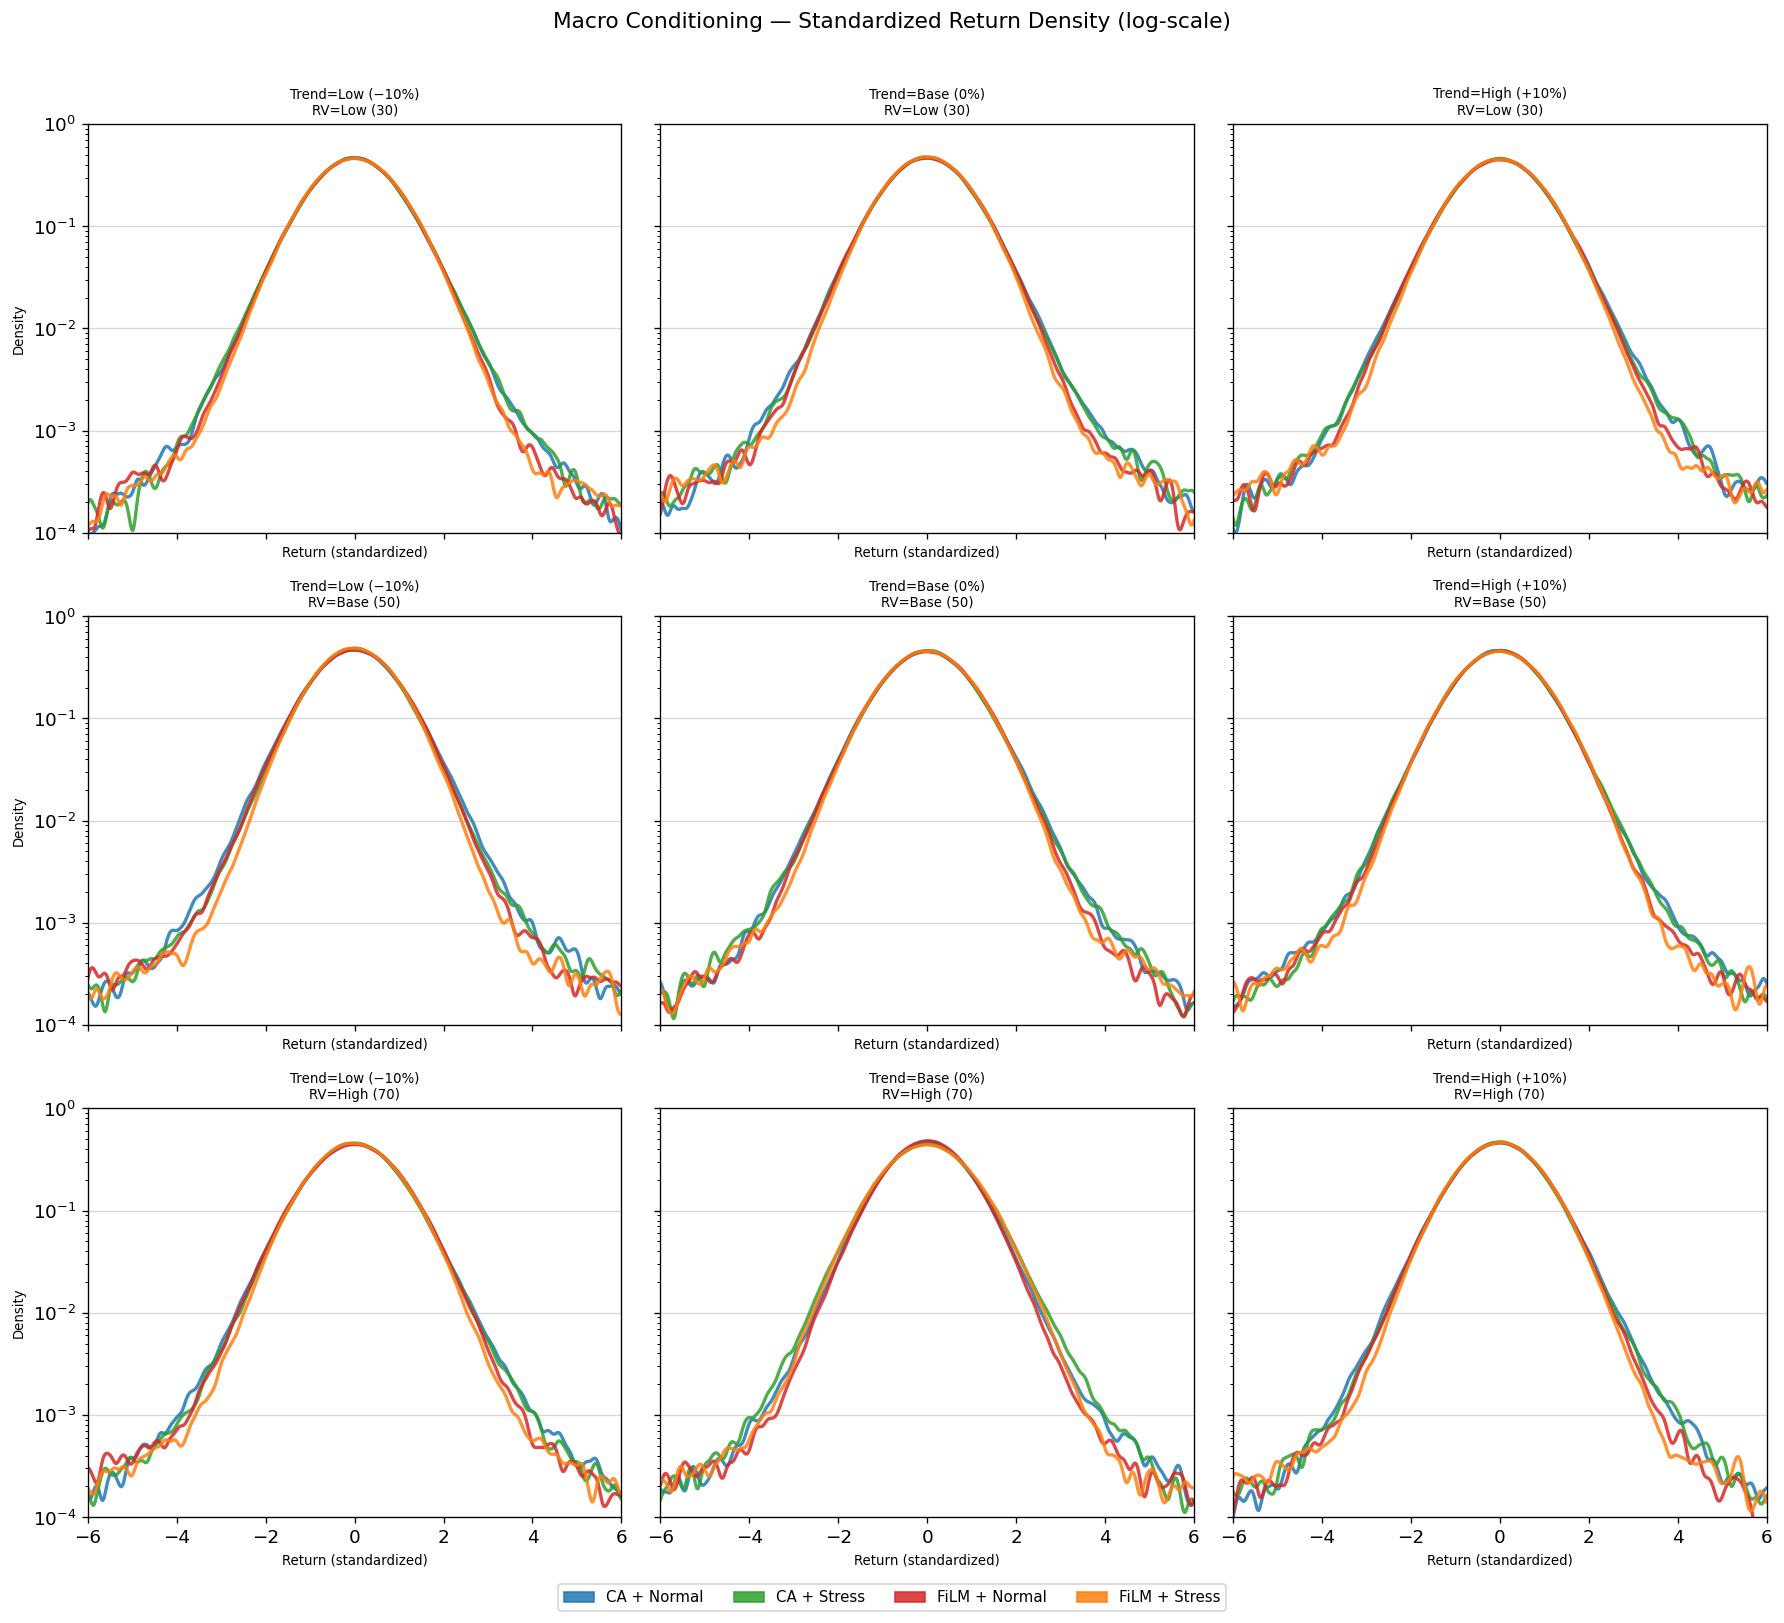

In [40]:
"""
Output 2 — Standardized KDE with log-scale y-axis.
Standardize returns within each group, then plot KDE on log y-axis.
3×3 grid; 4 overlapping curves per panel.
"""

x_grid = np.linspace(-6, 6, 500)

fig, axes = plt.subplots(3, 3, figsize=(15, 13), sharex=True, sharey=True)

for row_idx, rv in enumerate(RVS):
    for col_idx, trend in enumerate(TRENDS):
        ax = axes[row_idx, col_idx]

        for model, macro_key, color, label in GROUPS:
            arr = gen_data[(model, macro_key)][(trend, rv)]  # (N, T)
            flat = arr.ravel()
            flat_std = (flat - flat.mean()) / flat.std()
            kde_vals = gaussian_kde(flat_std, bw_method='scott')(x_grid)
            ax.plot(x_grid, kde_vals, color=color, lw=2, alpha=0.85)

        ax.set_yscale('log')
        ax.set_ylim(1e-4, 1.0)
        ax.set_xlim(-6, 6)
        ax.set_xlabel('Return (standardized)', fontsize=8)
        ax.set_title(f'Trend={TREND_LABELS[trend]}\nRV={RV_LABELS[rv]}', fontsize=8)
        ax.grid(axis='y', alpha=0.5)

    axes[row_idx, 0].set_ylabel('Density', fontsize=8)

# Shared legend
handles = [mpatches.Patch(color=g[2], alpha=0.85, label=g[3]) for g in GROUPS]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Macro Conditioning — Standardized Return Density (log-scale)', fontsize=13, y=1.01)

plt.tight_layout()
plt.savefig('../../figures/macro_kde_log.png', bbox_inches='tight')
plt.show()


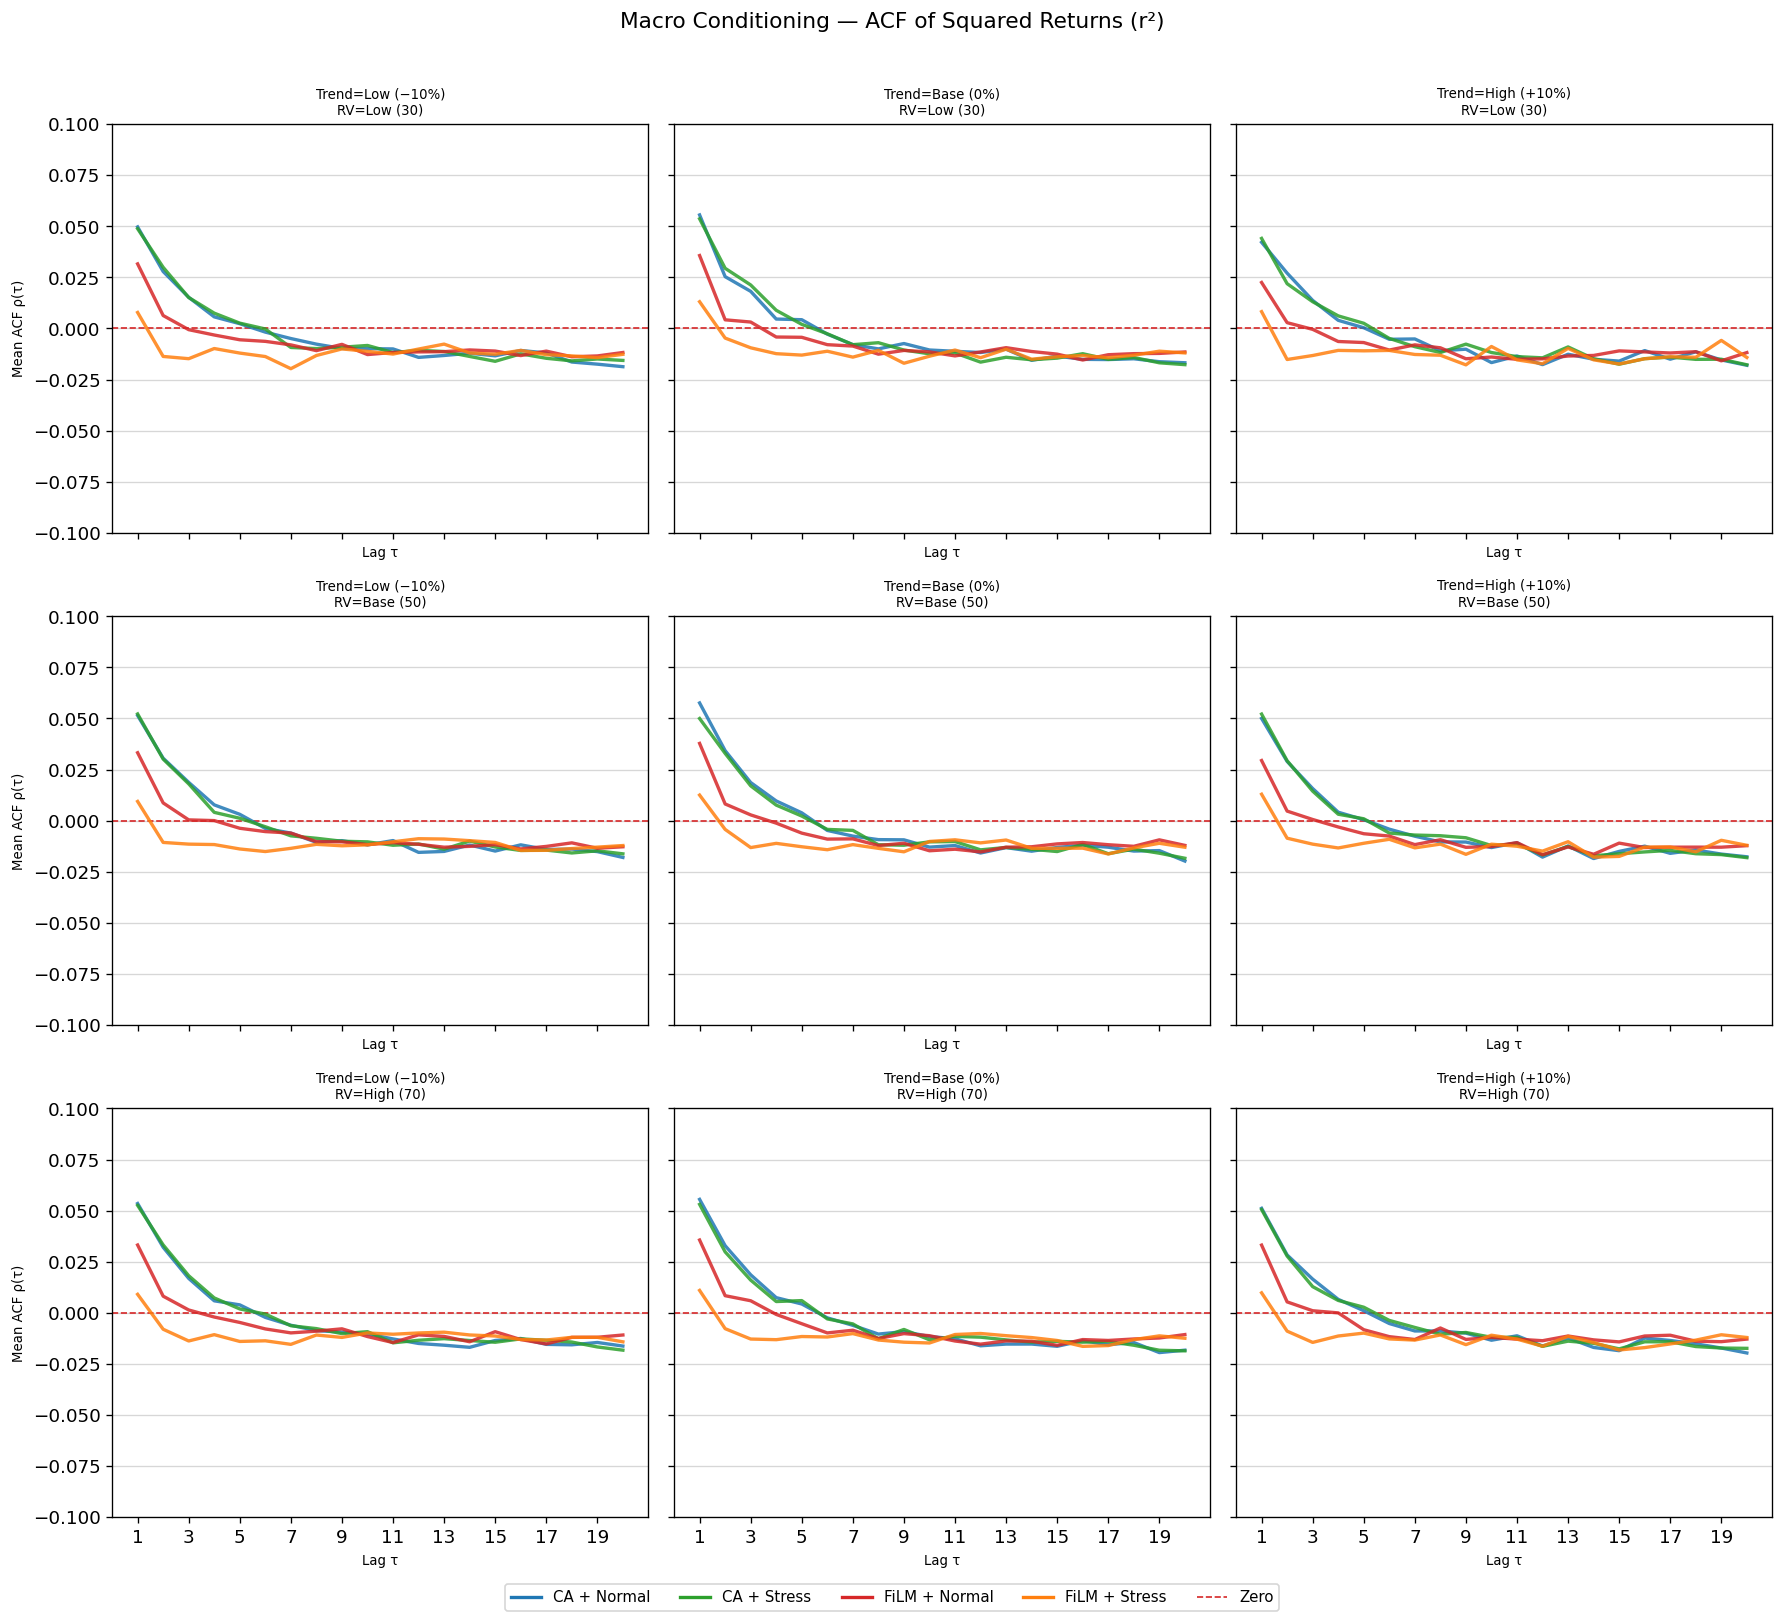

In [41]:
"""
Output 3 — ACF of squared returns.
3×3 grid; overlay 4 group ACF curves per panel.
"""

ALL_LAGS = np.arange(1, 21)  # lags 1–20

fig, axes = plt.subplots(3, 3, figsize=(15, 13), sharex=True, sharey=True)

for row_idx, rv in enumerate(RVS):
    for col_idx, trend in enumerate(TRENDS):
        ax = axes[row_idx, col_idx]

        ax.axhline(0, color=C_NORMAL, linestyle='--', linewidth=1.0)

        for model, macro_key, color, label in GROUPS:
            arr = gen_data[(model, macro_key)][(trend, rv)]  # (N, T)
            acf_vals = acf_squared(arr, ALL_LAGS)
            ax.plot(ALL_LAGS, acf_vals, color=color, lw=2, alpha=0.85)

        ax.set_xlim(0, 21)
        ax.set_xticks(np.arange(1, 21, 2))
        ax.set_ylim(-0.1, 0.1)
        ax.set_xlabel('Lag τ', fontsize=8)
        ax.set_title(f'Trend={TREND_LABELS[trend]}\nRV={RV_LABELS[rv]}', fontsize=8)
        ax.grid(axis='y', alpha=0.5)

    axes[row_idx, 0].set_ylabel('Mean ACF ρ(τ)', fontsize=8)

# Shared legend
handles = [Line2D([0], [0], color=g[2], lw=2, label=g[3]) for g in GROUPS]
zero_handle = Line2D([0], [0], color=C_NORMAL, linestyle='--', linewidth=1.0, label='Zero')
fig.legend(handles=handles + [zero_handle], loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Macro Conditioning — ACF of Squared Returns (r²)', fontsize=13, y=1.01)

plt.tight_layout()
plt.savefig('../../figures/macro_acf_sq.png', bbox_inches='tight')
plt.show()


In [42]:
"""
3.6 - Kurtosis comparison table.
"""

group_labels = [g[3] for g in GROUPS]  # column names

rows = []
index_tuples = []

for rv in RVS:
    for trend in TRENDS:
        row = []
        for model, macro_key, color, label in GROUPS:
            arr = gen_data[(model, macro_key)][(trend, rv)]  # (N, T)
            k = fisher_kurtosis(arr).mean()
            row.append(k)
        rows.append(row)
        index_tuples.append((f'{rv}', f'{trend}'))

idx = pd.MultiIndex.from_tuples(index_tuples, names=['Realized Vol', 'Trend (%)'])
df_kurt = pd.DataFrame(rows, index=idx, columns=group_labels)
print("Fisher Excess Kurtosis (mean across sequences)")
print("=" * 80)
print(df_kurt.to_string(float_format='{:.3f}'.format))


Fisher Excess Kurtosis (mean across sequences)
                        CA + Normal  CA + Stress  FiLM + Normal  FiLM + Stress
Realized Vol Trend (%)                                                        
30           -10              0.856        0.908          0.379          0.214
             0                0.866        0.871          0.384          0.209
             10               0.863        0.875          0.390          0.220
50           -10              0.878        0.887          0.404          0.207
             0                0.834        0.879          0.378          0.209
             10               0.875        0.855          0.381          0.210
70           -10              0.915        0.856          0.394          0.222
             0                0.858        0.870          0.398          0.210
             10               0.896        0.873          0.423          0.197
